<a href="https://colab.research.google.com/github/hsmu-jeongeun/machine-learning-practice/blob/main/250402_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 선형 회귀

## k-최근접 이웃의 한계

In [41]:
import numpy as np

# 농어의 길이 데이터
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )

# 농어의 무게 데이터
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [42]:
from sklearn.model_selection import train_test_split

# 훈련 세트와 테스트 세트 구분
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

# 2차원 배열로 변환
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [43]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [44]:
print(knr.predict([[50]]))

[1033.33333333]


In [45]:
import matplotlib.pyplot as plt

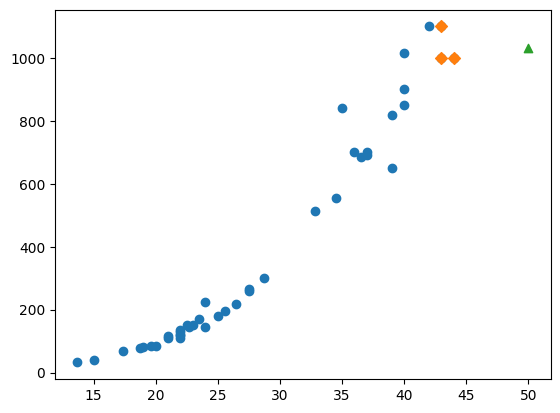

In [62]:
distances, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target) # train set -> blue
plt.scatter(train_input[indexes], train_target[indexes], marker='D') # neighbors = 3 -> orange
plt.scatter(50, 1033, marker='^') 
plt.show()

In [47]:
print(np.mean(train_target[indexes]))

1033.3333333333333


In [48]:
print(knr.predict([[100]]))

[1033.33333333]


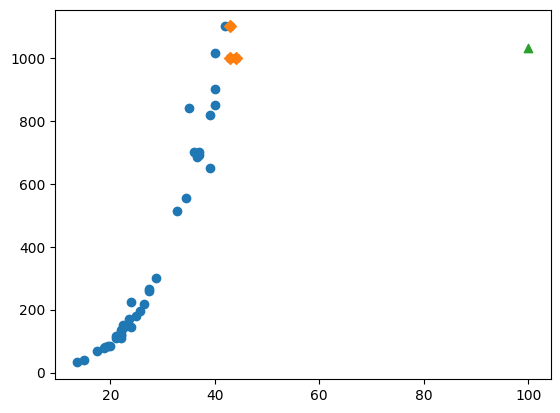

In [49]:
distances, indexes = knr.kneighbors([[100]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
plt.scatter(100, 1033, marker='^')
plt.show()

## 선형 회귀

In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
# 선형 회귀 모델 훈련
lr = LinearRegression()
lr.fit(train_input, train_target)

LinearRegression()

In [52]:
print(lr.predict([[50]]))

[1241.83860323]


In [53]:
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535477


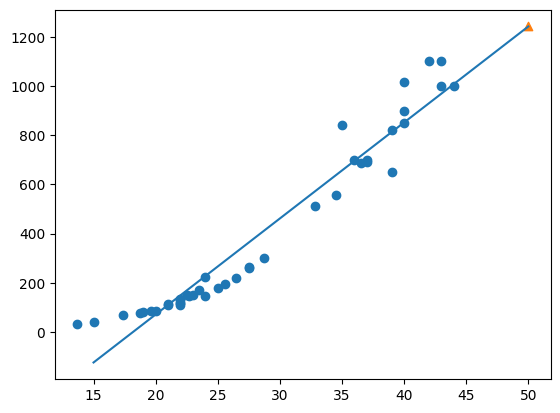

In [54]:
plt.scatter(train_input, train_target)
plt.plot([15, 50], [15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_])
plt.scatter(50, 1241.8, marker='^')
plt.show()

In [55]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

# 결과 : 과대적합? 과소적합?
# 트레인 세트 점수 > ㅌ테스트 세트 점수 -> 과대적합

0.9398463339976041
0.8247503123313559


## 다항 회귀

In [56]:
# 길이 특성을 제곱해서 또 다른 특성으로 사용
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))
print(train_poly[0:5,])
print(test_poly[0:5,])

[[ 384.16   19.6 ]
 [ 484.     22.  ]
 [ 349.69   18.7 ]
 [ 302.76   17.4 ]
 [1296.     36.  ]]
[[ 70.56   8.4 ]
 [324.    18.  ]
 [756.25  27.5 ]
 [453.69  21.3 ]
 [506.25  22.5 ]]


In [57]:
print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


In [58]:
lr = LinearRegression()
lr.fit(train_poly, train_target)

print(lr.predict([[50**2, 50]]))

[1573.98423528]


In [59]:
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.05021078278247


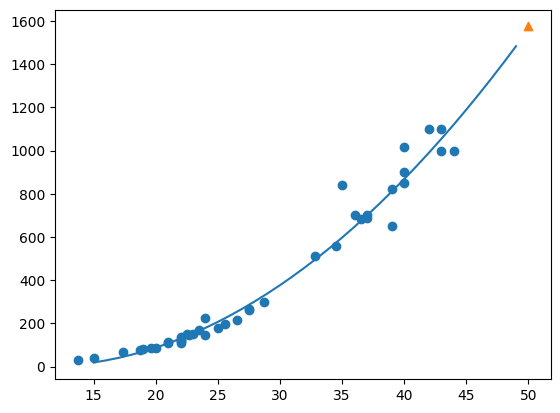

In [60]:
point = np.arange(15, 50)
plt.scatter(train_input, train_target)
plt.plot(point, 1.01*point**2 - 21.6*point + 116.05)
plt.scatter([50], [1574], marker='^')
plt.show()

In [65]:
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

# 결과 : 과대적합, 과소적합?
# 트레인 세트 점수 < 테스트 세트 점수 -> 과소적합 
# BUT 점수가 높고 차이가 적기에 과소적합이라고 결단하기는 어려움

0.9706807451768623
0.9775935108325121
